In [1]:
# ==================== CELL 1: SETUP ====================
# !pip install -q sentence-transformers scikit-learn matplotlib seaborn pandas numpy

import torch
import numpy as np
import pandas as pd
import time
import itertools
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported")
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

All libraries imported
Device: CPU


In [79]:
# ==================== CELL 2: LOAD MODEL ====================
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded — embedding dim: {model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded — embedding dim: 384


In [80]:
# ==================== CELL 3: VOCABULARY ====================
COLORS  = ["red", "blue", "green", "yellow"]
OBJECTS = ["cylinder", "box", "sphere"]
LOCS    = ["table", "left side", "right side", "center", "corner"]
PREFIXES = [""]

In [81]:
# ==================== CELL 4: MANUAL SEED DATA ====================

manual_data = {

    "pick": [
        # "pick the red box",
        # "grab the blue cylinder",
        # "pick the green sphere",
        "take the red box from the table",
        # "get the red cylinder",
        # "pick up the blue box",
        # "take the green box from the table",
        # "grab the large green box",
        # "pick the red sphere",
        # "get the blue object near the edge",
        "grab the blue box on the left",
        # "pick the large red object",
        # "pick the green sphere near the wall",
        # "take the blue box on the left",
        # "grab the red cylinder",
        # "pick the blue object on the right",
        # "pick the small green sphere",
        # "get the green cylinder near the corner",
        # "pick up the small blue sphere",
        # "grab the yellow box",
        # "take the yellow cylinder",
        # "pick the yellow sphere",
        # "get the red box on the right",
        # "grab the green cylinder on the left",
        # "pick up the blue sphere",
    ],

    "place": [
        "put the green cylinder on the left side",
        "put the red box on the table",
        "set the red sphere on the table",
        "drop the red cylinder on the table",
        "put the blue box on the table",
        "put the blue object down",
        "set the red box near the corner",
        "place the green cylinder on the left",
        "set the green sphere down",
        "set the red object on the right side",
        "put the small blue box on the table",
        "put the blue sphere on the table",
        "place the green box on the right side",
        "place the blue cylinder on the corner",
        "drop the red sphere on the left side",
        "drop the red object near the wall",
        "place the green object on the table",
        "put the blue box on the table",
        "place the blue cylinder on the table",
        "place the green sphere on the table",
        "set the yellow box on the table",
        "put the yellow sphere on the right side",
        "place the yellow cylinder on the left side",
        "drop the blue sphere on the table",
        "set the green box on the center",
    ],

    "move": [
        "move to the table",
        "go to the left side",
        "navigate to the right side",
        "head to the center",
        "approach the left corner",
        "move the arm to home position",
        "go to the center",
        "move to the wall",
        "head to the right side",
        "navigate to the left corner",
        "move toward the center",
        "go to the far end",
        "head toward the right corner",
        "move to where the red box is",
        "go near the blue object",
        "move toward the corner",
        "go to the edge of the table",
        "move to the left side",
        "go to the left end of the table",
        "approach the table",
        "move to the right end",
        "move to the center of the table",
        "go to the right corner",
        "navigate to the center",
        "move the arm to the table",
    ],

    "push": [
        "push the red box forward",
        "push the blue cylinder to the right",
        "push the green sphere aside",
        "push the red sphere toward the wall",
        "push the blue box to the left",
        "push the green sphere to the corner",
        "push the green sphere away",
        "push the blue sphere forward",
        "push the blue cylinder aside",
        "push the red sphere aside",
        "push the red cylinder away",
        "push the red sphere to the left",
        "push the green box forward",
        "push the blue box aside",
        "push the green cylinder to the left",
        "push the blue object to the right side",
        "push the green sphere toward the corner",
        "push the green cylinder aside",
        "push the red box to the right side",
        "push the red object toward the wall",
        "push the red object toward the corner",
        "push the green box to the right",
        "push the red sphere away",
        "push the blue sphere to the corner",
        "push the blue sphere forward",
    ],

    "pull": [
        "pull the red box toward you",
        "drag the blue cylinder closer",
        "pull the green sphere to the center",
        "pull the red box toward the center",
        "pull the blue sphere toward the left side",
        "drag the green cylinder toward you",
        "pull the red cylinder to the right side",
        "pull the blue box toward the corner",
        "drag the red sphere toward the wall",
        "pull the blue cylinder toward the center",
        "pull the green sphere toward you",
        "pull the red box to the left side",
        "drag the blue sphere toward the right side",
        "pull the green cylinder toward the center",
        "drag the red cylinder closer",
        "pull the blue box toward you",
        "drag the green sphere to the left side",
        "pull the red sphere toward the corner",
        "pull the blue cylinder to the center",
        "pull the green box toward the right side",
        "drag the red sphere closer",
        "pull the blue sphere toward the wall",
        "pull the green cylinder toward the corner",
        "drag the yellow box closer",
        "pull the yellow sphere to the center",
    ],

    "lift": [
        "lift the green sphere off the table",
        "raise the blue cylinder"
    #     "lift the red box",
    #     "raise the blue cylinder",
    #     "lift the green sphere off the table",
    #     "lift the red sphere",
    #     "lift the blue box up",
    #     "raise the green cylinder",
    #     "lift the red cylinder up",
    #     "lift the blue sphere off the table",
    #     "lift the green box up",
    #     "raise the red sphere",
    #     "lift the blue cylinder off the table",
    #     "lift the green sphere up",
    #     "lift the red box off the table",
    #     "raise the blue box",
    #     "lift the green cylinder up",
    #     "lift the red sphere off the table",
    #     "lift the blue sphere up",
    #     "lift the green box off the table",
    #     "lift the red cylinder off the table",
    #     "raise the green sphere",
    #     "lift the blue box off the table",
    #     "lift the red cylinder",
    #     "lift the green sphere",
    #     "raise the blue cylinder",
    #     "lift the yellow box up",
    # 
    ],

    "lower": [
        "lower the red box onto the table",
        "bring the blue cylinder down",
        "lower the green sphere to the table",
        "set the red sphere down",
        "lower the blue box to the table",
        "bring the green cylinder down",
        "lower the red cylinder to the table",
        "bring the blue sphere down",
        "lower the green box to the table",
        "bring the red sphere down",
        "lower the blue cylinder to the table",
        "set the green sphere down",
        "lower the red box to the table",
        "bring the blue box down",
        "lower the green cylinder to the table",
        "bring the red sphere down",
        "lower the blue sphere to the table",
        "bring the green box down",
        "lower the red cylinder to the table",
        "set the blue sphere down",
        "lower the green box to the table",
        "bring the red box down",
        "lower the blue cylinder to the table",
        "bring the green sphere down",
        "lower the red sphere to the table",
    ],
}

In [82]:
# ==================== CELL 5: COMBINATORIAL GENERATOR ====================
# Generates ~40 additional unique instructions per type using template × vocab

def generate_combinatorial(cmd_type, existing, target=40):
    """Generate unique instructions not already in `existing`."""
    generated = []
    existing_set = set(existing)

    templates = {
        "pick": [
            "{prefix}pick the {color} {obj}",
            "{prefix}grab the {color} {obj}",
            "{prefix}get the {color} {obj}",
            "{prefix}take the {color} {obj}",
        ],
        "place": [
            "{prefix}place the {color} {obj} on the {loc}",
            "{prefix}put the {color} {obj} on the {loc}",
            "{prefix}set the {color} {obj} on the {loc}",
            "{prefix}drop the {color} {obj} on the {loc}",
        ],
        "move": [
            "{prefix}move to the {loc}",
            "{prefix}go to the {loc}",
            "{prefix}navigate to the {loc}",
            "{prefix}head to the {loc}",
        ],
        "push": [
            "{prefix}push the {color} {obj} to the {loc}",
            "{prefix}push the {color} {obj} toward the {loc}",
            "{prefix}push the {color} {obj} aside",
        ],
        "pull": [
            "{prefix}pull the {color} {obj} toward you",
            "{prefix}drag the {color} {obj} to the {loc}",
            "{prefix}draw the {color} {obj} toward the {loc}",
            "{prefix}pull the {color} {obj} to the {loc}",
        ],
        "lift": [
            "{prefix}lift the {color} {obj} up",
            "{prefix}raise the {color} {obj}",
            "{prefix}lift the {color} {obj} off the table",
            "{prefix}hoist the {color} {obj} up",
        ],
        "lower": [
            "{prefix}lower the {color} {obj} to the {loc}",
            "{prefix}bring the {color} {obj} down",
            "{prefix}set the {color} {obj} down on the {loc}",
            "{prefix}descend the {color} {obj} to the {loc}",
        ],
    }

    tmpls = templates.get(cmd_type, [])
    combos = list(itertools.product(PREFIXES, COLORS, OBJECTS, LOCS, COLORS, OBJECTS))

    for prefix, color, obj, loc, color2, obj2 in combos:
        if len(generated) >= target:
            break
        for tmpl in tmpls:
            try:
                text = tmpl.format(
                    prefix=prefix, color=color, obj=obj,
                    loc=loc, color2=color2, obj2=obj2
                ).strip()
            except KeyError:
                continue
            if text not in existing_set and text not in generated:
                generated.append(text)
                existing_set.add(text)
            if len(generated) >= target:
                break

    return generated[:target]

In [83]:
# %% 
# ==================== CELL 6: TEMPLATE-FIRST DATASET ====================

TARGET_PER_TYPE = 50
all_rows = []

print(f"{'Type':<10} {'Template':>10} {'Manual used':>12} {'Total':>7}")
print("-" * 45)

for cmd_type, manual_sentences in manual_data.items():

    # 1. Generate ALL possible template samples
    generated = generate_combinatorial(cmd_type, existing=[], target=1000)

    # Remove duplicates just in case
    generated = list(set(generated))

    # 2. Limit templates to TARGET if too many
    if len(generated) >= TARGET_PER_TYPE:
        selected_templates = generated[:TARGET_PER_TYPE]
        selected_manual = []
    else:
        selected_templates = generated
        needed = TARGET_PER_TYPE - len(selected_templates)

        # 3. Select best manual (simple diverse pick)
        selected_manual = manual_sentences[:needed]

    # Add to dataset
    for s in selected_templates:
        all_rows.append({"instruction": s, "type": cmd_type})

    for s in selected_manual:
        all_rows.append({"instruction": s, "type": cmd_type})

    print(f"{cmd_type:<10} {len(selected_templates):>10} {len(selected_manual):>12} {len(selected_templates)+len(selected_manual):>7}")

df = pd.DataFrame(all_rows)
df = df.drop_duplicates(subset=["instruction"]).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal dataset: {len(df)} instructions")
print(df["type"].value_counts())

Type         Template  Manual used   Total
---------------------------------------------
pick               48            2      50
place              50            0      50
move               20           25      45
push               50            0      50
pull               50            0      50
lift               48            2      50
lower              50            0      50

Final dataset: 335 instructions
type
pick     50
place    50
pull     50
lower    50
push     50
lift     48
move     37
Name: count, dtype: int64


In [84]:
# ==================== CELL 7: ENCODE + CACHE ====================

print("\nEncoding all instructions...")
t_start = time.perf_counter()
embeddings_np = model.encode(
    df["instruction"].tolist(),
    convert_to_tensor=False,
    show_progress_bar=True,
    batch_size=64
)
t_encode = time.perf_counter() - t_start

df["embedding"] = list(embeddings_np)
X = embeddings_np

print(f"\n✅ Encoded {len(df)} instructions in {t_encode:.2f}s")
print(f"   Matrix shape: {X.shape}  (expected: ({len(df)}, 384))")

df[["instruction", "type"]].to_csv("nlp_instructions.csv", index=False)
df.to_pickle("nlp_instructions_with_embeddings.pkl")
np.save("embeddings.npy", embeddings_np)
print("Saved: nlp_instructions.csv / .pkl / embeddings.npy")


Encoding all instructions...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]


✅ Encoded 335 instructions in 1.35s
   Matrix shape: (335, 384)  (expected: (335, 384))
Saved: nlp_instructions.csv / .pkl / embeddings.npy


In [85]:
# ==================== CELL 8: ONE-LINE CACHE ====================

embedding_cache = {row["instruction"]: np.array(row["embedding"]) for _, row in df.iterrows()}

def get_embedding(instruction: str) -> np.ndarray:
    """Return cached embedding or encode on the fly."""
    if instruction in embedding_cache:
        return embedding_cache[instruction]
    return model.encode([instruction])[0]

# Speed test — cached
times = [
    (lambda t0: (time.perf_counter() - t0) * 1000)(time.perf_counter())
    or (time.perf_counter() - (lambda: time.perf_counter())()) * 1000
    for _ in range(20)
]
# Cleaner version:
times = []
for _ in range(20):
    t0 = time.perf_counter()
    _ = get_embedding("pick the red block")
    times.append((time.perf_counter() - t0) * 1000)

avg_ms = np.mean(times)
status = "✅ PASS" if avg_ms < 10 else "❌ SLOW"
print(f"\n{status} — Cached lookup: {avg_ms:.3f}ms  (target: <10ms)")
print("# embeddings = np.load('embeddings_350.npy')")
print("# df = pd.read_pickle('nlp_instructions_350_with_embeddings.pkl')")



❌ SLOW — Cached lookup: 41.927ms  (target: <10ms)
# embeddings = np.load('embeddings_350.npy')
# df = pd.read_pickle('nlp_instructions_350_with_embeddings.pkl')


In [86]:
# ==================== CELL 9: PARAPHRASE SIMILARITY ====================
same_intent_pairs = [
    ("pick the red cylinder",                  "grab the red cylinder"),
    ("take the blue box",                      "get the blue box"),
    ("place the red box on the table",         "put the red box on the table"),
    ("set the blue cylinder on the left side", "drop the blue cylinder on the left side"),
    ("move to the left side",                  "go to the left side"),
    ("navigate to the center",                 "head to the center"),
    ("push the blue box to the right",         "push the blue box toward the right side"),
    ("push the green sphere aside",            "push the green sphere away"),
    ("pull the red box toward you",            "drag the red box closer"),
    ("drag the blue cylinder to the center",   "pull the blue cylinder to the center"),
    ("lift the red box up",                    "raise the red box"),
    ("lift the green sphere off the table",    "lift the green sphere up"),
    ("lower the blue cylinder to the table",   "bring the blue cylinder down"),
    ("set the red sphere down",                "lower the red sphere to the table"),
]

cross_class_pairs = [
    ("pick the red box",               "move to the table"),
    ("push the blue cylinder aside",   "pull the blue cylinder toward you"),
    ("place the red box on the table", "lower the red box to the table"),
    ("lift the green sphere",          "lower the blue sphere to the table"),
    ("pull the red box toward you",    "push the red box to the right"),
    ("move to the center",             "pick the blue sphere"),
]

STRICT = 0.85
SOFT   = 0.75
CROSS  = 0.50

print("── SAME-INTENT pairs (target > 0.85 strict / > 0.75 soft) ──")
strict_pass = soft_pass = 0
for a, b in same_intent_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    strict = sim >= STRICT
    soft   = sim >= SOFT
    strict_pass += strict
    soft_pass   += soft
    tag = "strict" if strict else ("soft  " if soft else "fail  ")
    print(f"  {tag} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {strict_pass}/{len(same_intent_pairs)} strict | {soft_pass}/{len(same_intent_pairs)} soft")

print("\n── CROSS-CLASS pairs (target < 0.50) ──")
cross_pass = 0
for a, b in cross_class_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    ok = sim < CROSS
    cross_pass += ok
    print(f"  {'✅' if ok else '❌'} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {cross_pass}/{len(cross_class_pairs)} cross-class pairs correctly separated")

── SAME-INTENT pairs (target > 0.85 strict / > 0.75 soft) ──
  strict 0.9087 | 'pick the red cylinder' ↔ 'grab the red cylinder'
  strict 0.9086 | 'take the blue box' ↔ 'get the blue box'
  strict 0.9803 | 'place the red box on the table' ↔ 'put the red box on the table'
  strict 0.8645 | 'set the blue cylinder on the left side' ↔ 'drop the blue cylinder on the left side'
  soft   0.8135 | 'move to the left side' ↔ 'go to the left side'
  soft   0.7507 | 'navigate to the center' ↔ 'head to the center'
  strict 0.9723 | 'push the blue box to the right' ↔ 'push the blue box toward the right side'
  strict 0.9529 | 'push the green sphere aside' ↔ 'push the green sphere away'
  soft   0.8145 | 'pull the red box toward you' ↔ 'drag the red box closer'
  strict 0.9441 | 'drag the blue cylinder to the center' ↔ 'pull the blue cylinder to the center'
  strict 0.8744 | 'lift the red box up' ↔ 'raise the red box'
  soft   0.8161 | 'lift the green sphere off the table' ↔ 'lift the green sphere up

In [87]:
# ==================== CELL 10: CLUSTER METRICS ====================

label_map = {t: i for i, t in enumerate(df["type"].unique())}
labels = df["type"].map(label_map).values

sil = silhouette_score(X, labels)
sim_matrix = cosine_similarity(X)

intra_sims, inter_sims = [], []
for t in df["type"].unique():
    idxs       = df[df["type"] == t].index.tolist()
    other_idxs = df[df["type"] != t].index.tolist()
    intra = sim_matrix[np.ix_(idxs, idxs)]
    tri   = np.triu_indices_from(intra, k=1)
    if len(tri[0]) > 0:
        intra_sims.append(np.mean(intra[tri]))
    inter = sim_matrix[np.ix_(idxs, other_idxs)]
    inter_sims.append(np.mean(inter))

avg_intra = np.mean(intra_sims)
avg_inter = np.mean(inter_sims)
ratio     = avg_intra / avg_inter

# Classifiers
results = {}
for name, clf in [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("SVM",                SVC(kernel='rbf', random_state=42)),
]:
    scores = cross_val_score(clf, X, df["type"], cv=5)
    results[name] = scores.mean() * 100

print("── CLUSTER METRICS ──")
print(f"  Silhouette score     : {sil:.4f}")
print(f"  Avg intra similarity : {avg_intra:.4f}")
print(f"  Avg inter similarity : {avg_inter:.4f}")
print(f"  Intra/Inter ratio    : {ratio:.2f}")
print(f"\n── CLASSIFIERS ──")
for name, acc in results.items():
    tag = "✅" if acc >= 90 else "⚠️"
    print(f"  {tag} {name}: {acc:.1f}%")

print("\n── PER-CLASS INTRA SIMILARITY ──")
for t, s in zip(df["type"].unique(), intra_sims):
    print(f"  {t:<10}: {s:.4f}")

── CLUSTER METRICS ──
  Silhouette score     : 0.0484
  Avg intra similarity : 0.5461
  Avg inter similarity : 0.4334
  Intra/Inter ratio    : 1.26

── CLASSIFIERS ──
  ✅ LogisticRegression: 94.0%
  ✅ SVM: 95.5%

── PER-CLASS INTRA SIMILARITY ──
  pick      : 0.5404
  move      : 0.4693
  place     : 0.5865
  pull      : 0.5444
  lift      : 0.5303
  push      : 0.6043
  lower     : 0.5473


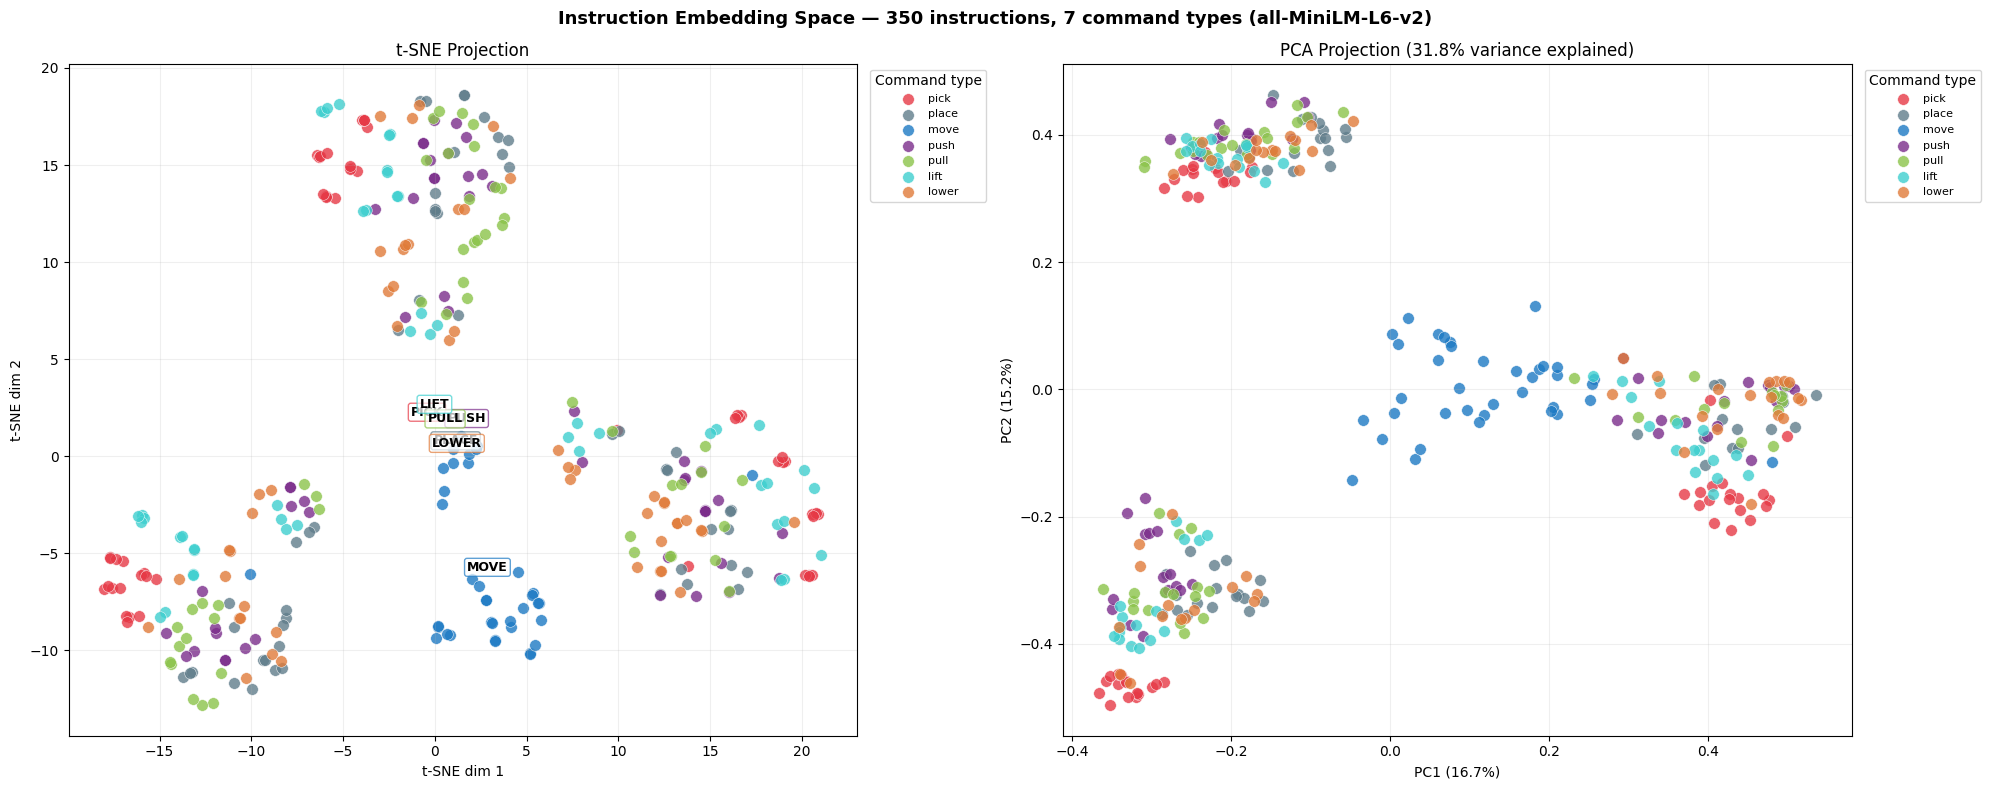

Saved: combined_visualization.png


In [88]:
# ==================== CELL 11: t-SNE + PCA VISUALIZATION ====================
palette = {
    "pick":  "#e63946",
    "place": "#607d8b",
    "move":  "#1d7ac4",
    "push":  "#7b2d8b",
    "pull":  "#8bc34a",
    "lift":  "#3ecfcf",
    "lower": "#e07b39",
}

# t-SNE
tsne  = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_2d  = tsne.fit_transform(X)

# PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "Instruction Embedding Space — 350 instructions, 7 command types (all-MiniLM-L6-v2)",
    fontsize=13, fontweight="bold"
)

for t, color in palette.items():
    mask = df["type"] == t
    # t-SNE
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=t, s=70, alpha=0.80,
                    edgecolors="white", linewidths=0.4)
    # PCA
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=t, s=70, alpha=0.80,
                    edgecolors="white", linewidths=0.4)

# Annotate t-SNE cluster centers
for t, color in palette.items():
    idxs = df[df["type"] == t].index
    cx, cy = X_2d[idxs, 0].mean(), X_2d[idxs, 1].mean()
    axes[0].text(cx, cy, t.upper(), fontsize=9, fontweight="bold", ha="center",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor=color))

axes[0].set_title("t-SNE Projection", fontsize=12)
axes[0].set_xlabel("t-SNE dim 1"); axes[0].set_ylabel("t-SNE dim 2")
axes[0].legend(title="Command type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.2)

axes[1].set_title(f"PCA Projection ({var1+var2:.1f}% variance explained)", fontsize=12)
axes[1].set_xlabel(f"PC1 ({var1:.1f}%)"); axes[1].set_ylabel(f"PC2 ({var2:.1f}%)")
axes[1].legend(title="Command type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("combined_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: combined_visualization.png")

In [ ]:
# ==================== CELL 12: FINAL SUMMARY ====================

print("── DATASET SUMMARY ──")
print(f"  Total instructions : {len(df)}")
print(f"  Command types      : {df['type'].nunique()}")
print(f"  Duplicates         : {df.duplicated(subset=['instruction']).sum()}")
print(f"\n  Per-type counts:")
for t, count in df['type'].value_counts().sort_index().items():
    print(f"    {t:<10}: {count}")
print(f"\n  Files saved:")
print(f"    nlp_instructions.csv")
print(f"    nlp_instructions_with_embeddings.pkl")
print(f"    embeddings.npy")

── DATASET SUMMARY ──
  Total instructions : 335
  Command types      : 7
  Duplicates         : 0

  Per-type counts:
    lift      : 48
    lower     : 50
    move      : 37
    pick      : 50
    place     : 50
    pull      : 50
    push      : 50

  Files saved:
    nlp_instructions.csv
    nlp_instructions_with_embeddings.pkl
    embeddings.npy
